# 0823_kimjaehak_003_feature_validity

> EDA 001에서 확인한 `inspection_type`별 매핑, 상수열, 매핑 제외 피처의 채움 패턴을 심층 분석합니다. 실제 행이나 불필요한 고유값은 출력하지 않고 집계 결과만 사용합니다.

## 분석 배경과 질문

원 논문 *Data of automated optical inspection of surface-mounted technology electronic production* (Pfab et al., 2024)은 검사유형에 따라 `inspection_feat`의 사용 여부와 물리적 의미가 달라지고, 미사용 피처에는 기본값 0이 들어간다고 설명합니다. 동시에 0은 유효 측정값일 수도 있다고 명시합니다. 따라서 값 자체가 아닌 `mapping.json`을 유효성의 기준으로 사용해야 합니다.

이 노트북은 다음 질문에 답합니다.

1. `mapping.json`이 데이터의 검사유형과 70개 검사 피처를 빠짐없이 설명하는가?
2. 유형별 유효 피처 중 상수·준상수·저분산 피처는 몇 개인가?
3. 매핑 제외 피처는 0, 0이 아닌 상수, 가변값 중 어떤 형태로 채워지는가?
4. 매핑 제외 값이 유효값의 값 집합과 겹쳐 값 기반 마스킹을 방해하는가?
5. 검사유형별 잠정 실사용 피처 후보는 몇 개이며 안전한 전처리 규칙은 무엇인가?

## 1. 설정과 라이브러리

원본 파일은 읽기만 하며 수정하지 않습니다. `RANDOM_STATE`는 프로젝트 기본값 42로 고정합니다.

In [1]:
from pathlib import Path
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

EXPERIMENT_ID = "0823_kimjaehak_003_feature_validity"
RANDOM_STATE = 42

candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (path for path in candidate_roots if (path / "data/raw/dataset.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("data/raw/dataset.csv를 찾을 수 없습니다. 저장소 루트에서 실행하세요.")

DATA_PATH = REPO_ROOT / "data/raw/dataset.csv"
MAPPING_PATH = REPO_ROOT / "data/raw/mapping.json"
PAPER_PATH = REPO_ROOT / "docs/1-s2.0-S2352340924000830-main.pdf"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("experiment:", EXPERIMENT_ID)
print("python:", platform.python_version())
print("pandas:", pd.__version__)
print("data file exists:", DATA_PATH.exists())
print("mapping file exists:", MAPPING_PATH.exists())
print("paper file exists:", PAPER_PATH.exists())

experiment: 0823_kimjaehak_003_feature_validity
python: 3.12.13
pandas: 3.0.5
data file exists: True
mapping file exists: True
paper file exists: True


## 2. 데이터 로딩과 매핑 완전성

CSV의 첫 번째 헤더 없는 식별자는 모델 피처에서 제외합니다. 매핑 키, 중복, 데이터에 없는 피처, 매핑에서 한 번도 사용되지 않는 피처를 집계로 검증합니다.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
with MAPPING_PATH.open(encoding="utf-8") as stream:
    mapping = json.load(stream)

source_index_column = df.columns[0]
if source_index_column.startswith("Unnamed:"):
    df = df.rename(columns={source_index_column: "record_id"})
elif source_index_column != "record_id":
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

TYPE_COLUMN = "inspection_type"
INSPECTION_COLUMNS = [column for column in df.columns if column.startswith("inspection_feat")]
inspection_types = sorted(df[TYPE_COLUMN].unique().tolist())
mapping_keys = sorted(int(key) for key in mapping)

mapping_rows = []
for inspection_type in inspection_types:
    mapped = mapping[str(inspection_type)]
    mapping_rows.append(
        {
            "inspection_type": inspection_type,
            "samples": int((df[TYPE_COLUMN] == inspection_type).sum()),
            "mapped_features": len(mapped),
            "duplicate_mapping_entries": len(mapped) - len(set(mapped)),
            "missing_from_dataset": len(set(mapped) - set(INSPECTION_COLUMNS)),
            "unmapped_dataset_features": len(set(INSPECTION_COLUMNS) - set(mapped)),
        }
    )
mapping_summary = pd.DataFrame(mapping_rows).set_index("inspection_type")

mapped_union = set().union(*(set(columns) for columns in mapping.values()))
mapped_intersection = set.intersection(*(set(columns) for columns in mapping.values()))
never_mapped_features = sorted(set(INSPECTION_COLUMNS) - mapped_union)
mapping_overview = pd.Series(
    {
        "dataset_inspection_types": len(inspection_types),
        "mapping_inspection_types": len(mapping_keys),
        "dataset_inspection_features": len(INSPECTION_COLUMNS),
        "features_mapped_at_least_once": len(mapped_union),
        "features_never_mapped": len(never_mapped_features),
        "features_mapped_in_all_types": len(mapped_intersection),
    },
    name="value",
)

assert inspection_types == mapping_keys, "데이터와 mapping.json의 inspection_type이 다릅니다."
assert mapping_summary["duplicate_mapping_entries"].sum() == 0, "매핑 내부에 중복 피처가 있습니다."
assert mapping_summary["missing_from_dataset"].sum() == 0, "매핑에 CSV에 없는 피처가 있습니다."

display(mapping_overview.to_frame())
display(mapping_summary)

,value
dataset_inspection_types,5
mapping_inspection_types,5
dataset_inspection_features,70
features_mapped_at_least_once,65
features_never_mapped,5
features_mapped_in_all_types,17


,samples,mapped_features,duplicate_mapping_entries,missing_from_dataset,unmapped_dataset_features
inspection_type,,,,,
0,97053,44,0,0,26
1,57673,52,0,0,18
2,128174,65,0,0,5
3,151931,65,0,0,5
4,5443,21,0,0,49


,feature_count
types_using_feature,
0,5
2,1
3,28
4,19
5,17


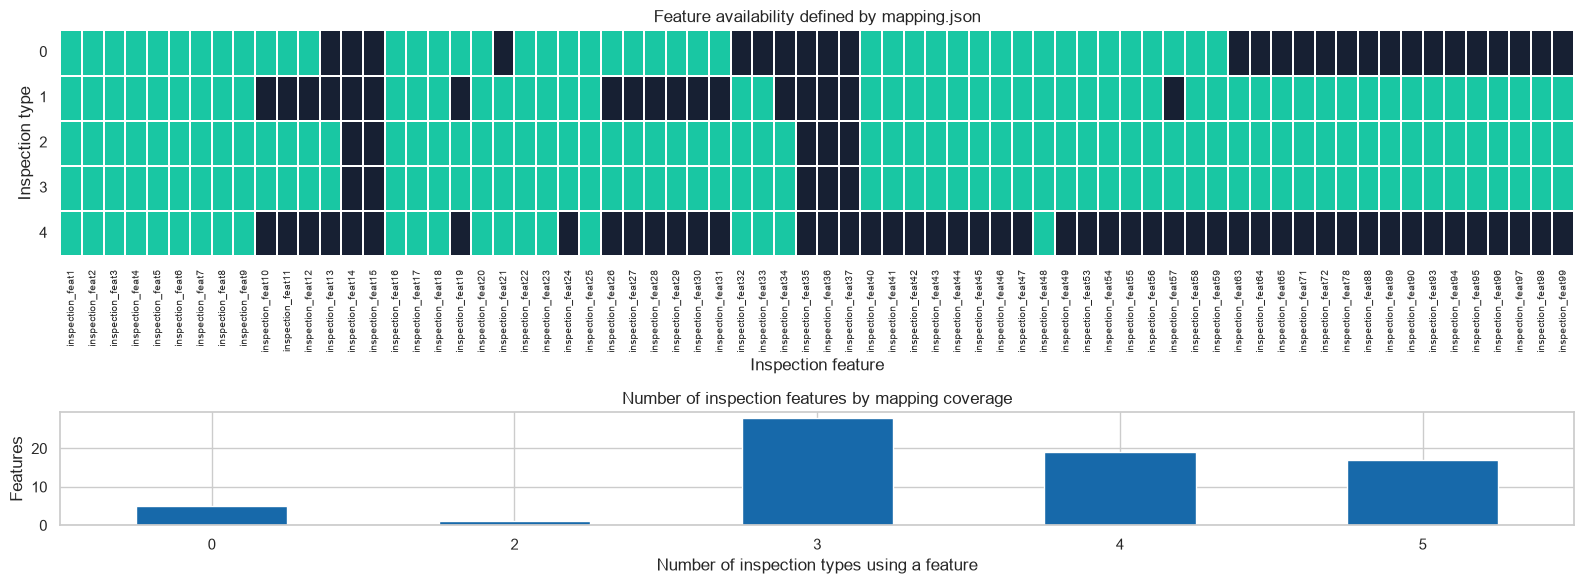

In [3]:
availability = pd.DataFrame(
    0, index=inspection_types, columns=INSPECTION_COLUMNS, dtype=int
)
for inspection_type in inspection_types:
    availability.loc[inspection_type, mapping[str(inspection_type)]] = 1

coverage_counts = availability.sum(axis=0).value_counts().sort_index()
coverage_summary = coverage_counts.rename_axis("types_using_feature").to_frame("feature_count")
display(coverage_summary)

fig, axes = plt.subplots(2, 1, figsize=(16, 6), gridspec_kw={"height_ratios": [2, 1]})
sns.heatmap(
    availability,
    cmap=sns.color_palette(["#172033", "#19c7a3"]),
    cbar=False,
    linewidths=0.05,
    ax=axes[0],
)
axes[0].set_title("Feature availability defined by mapping.json")
axes[0].set_xlabel("Inspection feature")
axes[0].set_ylabel("Inspection type")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].tick_params(axis="y", rotation=0)

coverage_summary["feature_count"].plot(kind="bar", color="#1769aa", ax=axes[1])
axes[1].set_title("Number of inspection features by mapping coverage")
axes[1].set_xlabel("Number of inspection types using a feature")
axes[1].set_ylabel("Features")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 3. 유효 피처의 상수·준상수·저분산 분류

70개 검사 피처는 논문에서 `[0, 1]`로 스케일되었다고 설명됩니다. 유형별 유효 피처를 다음의 상호 배타적 기준으로 분류합니다.

- **상수**: 고유값 수가 1개 이하
- **준상수**: 상수가 아니면서 최빈값 비율이 99% 이상
- **저분산**: 앞의 두 조건에 해당하지 않으면서 모집단 분산이 `1e-4` 이하(표준편차 0.01 이하)
- **잠정 후보**: 위 세 조건에 해당하지 않는 매핑된 검사 피처

여기서는 데이터 특성을 진단하기 위해 전체 기간을 사용합니다. 실제 모델 선택에서는 시간 분할 후 학습 데이터에만 같은 판정기를 적합해야 하며, 이 집계를 곧바로 제거 목록으로 사용하지 않습니다.

In [4]:
QUASI_CONSTANT_THRESHOLD = 0.99
LOW_VARIANCE_THRESHOLD = 1e-4

valid_detail_rows = []
for inspection_type in inspection_types:
    group = df.loc[df[TYPE_COLUMN] == inspection_type]
    for column in mapping[str(inspection_type)]:
        series = group[column]
        unique_count = int(series.nunique(dropna=False))
        variance = float(series.var(ddof=0))
        dominant_ratio = float(series.value_counts(dropna=False, normalize=True).iloc[0])
        is_constant = unique_count <= 1
        is_quasi_constant = (not is_constant) and dominant_ratio >= QUASI_CONSTANT_THRESHOLD
        is_low_variance = (
            (not is_constant)
            and (not is_quasi_constant)
            and variance <= LOW_VARIANCE_THRESHOLD
        )
        if is_constant:
            category = "constant"
        elif is_quasi_constant:
            category = "quasi_constant"
        elif is_low_variance:
            category = "low_variance"
        else:
            category = "candidate"
        valid_detail_rows.append(
            {
                "inspection_type": inspection_type,
                "feature": column,
                "unique_count": unique_count,
                "variance": variance,
                "dominant_ratio": dominant_ratio,
                "category": category,
            }
        )

valid_detail = pd.DataFrame(valid_detail_rows)
category_order = ["constant", "quasi_constant", "low_variance", "candidate"]
valid_category_counts = (
    pd.crosstab(valid_detail["inspection_type"], valid_detail["category"])
    .reindex(index=inspection_types, columns=category_order, fill_value=0)
)
valid_summary = valid_category_counts.copy()
valid_summary.insert(0, "mapped_features", valid_summary.sum(axis=1))
valid_summary["candidate_pct"] = (
    valid_summary["candidate"] / valid_summary["mapped_features"] * 100
)
display(valid_summary)

category,mapped_features,constant,quasi_constant,low_variance,candidate,candidate_pct
inspection_type,,,,,,
0,44,7,6,4,27,61.3636
1,52,28,9,3,12,23.0769
2,65,45,1,1,18,27.6923
3,65,46,1,1,17,26.1538
4,21,8,0,3,10,47.6190


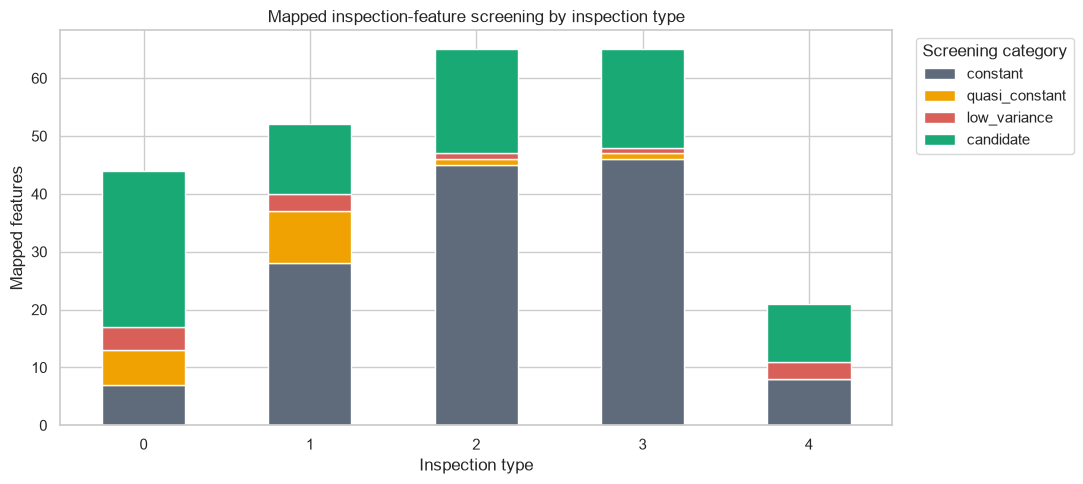

In [5]:
colors = ["#5f6b7a", "#f0a202", "#d95f59", "#19a974"]
ax = valid_category_counts[category_order].plot(
    kind="bar", stacked=True, figsize=(11, 5), color=colors
)
ax.set_title("Mapped inspection-feature screening by inspection type")
ax.set_xlabel("Inspection type")
ax.set_ylabel("Mapped features")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Screening category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. 매핑 제외 피처의 채움 패턴

각 `(inspection_type, inspection_feat)` 매핑 제외 조합을 `항상 0`, `0이 아닌 상수`, `가변값`으로 분류합니다. 셀 수준의 0/비0 비율과 피처별 고유값 수·분산도 집계하지만, 실제 채움값 자체는 출력하지 않습니다.

In [6]:
invalid_detail_rows = []
for inspection_type in inspection_types:
    group = df.loc[df[TYPE_COLUMN] == inspection_type]
    invalid_columns = sorted(set(INSPECTION_COLUMNS) - set(mapping[str(inspection_type)]))
    for column in invalid_columns:
        series = group[column]
        unique_count = int(series.nunique(dropna=False))
        zero_rate = float((series == 0).mean())
        if unique_count == 1 and zero_rate == 1.0:
            fill_pattern = "constant_zero"
        elif unique_count == 1:
            fill_pattern = "constant_nonzero"
        else:
            fill_pattern = "variable"
        invalid_detail_rows.append(
            {
                "inspection_type": inspection_type,
                "feature": column,
                "cells": len(series),
                "unique_count": unique_count,
                "variance": float(series.var(ddof=0)),
                "zero_rate": zero_rate,
                "nonzero_cells": int((series != 0).sum()),
                "fill_pattern": fill_pattern,
            }
        )

invalid_detail = pd.DataFrame(invalid_detail_rows)
fill_pattern_order = ["constant_zero", "constant_nonzero", "variable"]
invalid_pattern_counts = (
    pd.crosstab(invalid_detail["inspection_type"], invalid_detail["fill_pattern"])
    .reindex(index=inspection_types, columns=fill_pattern_order, fill_value=0)
)

invalid_summary_rows = []
for inspection_type in inspection_types:
    part = invalid_detail.loc[invalid_detail["inspection_type"] == inspection_type]
    total_cells = int(part["cells"].sum())
    nonzero_cells = int(part["nonzero_cells"].sum())
    invalid_summary_rows.append(
        {
            "inspection_type": inspection_type,
            "unmapped_features": len(part),
            "constant_zero": int((part["fill_pattern"] == "constant_zero").sum()),
            "constant_nonzero": int((part["fill_pattern"] == "constant_nonzero").sum()),
            "variable": int((part["fill_pattern"] == "variable").sum()),
            "invalid_cells": total_cells,
            "zero_cell_pct": (total_cells - nonzero_cells) / total_cells * 100,
            "nonzero_cell_pct": nonzero_cells / total_cells * 100,
            "median_unique_values": float(part["unique_count"].median()),
            "maximum_unique_values": int(part["unique_count"].max()),
        }
    )
invalid_summary = pd.DataFrame(invalid_summary_rows).set_index("inspection_type")
display(invalid_summary)

,unmapped_features,constant_zero,constant_nonzero,variable,invalid_cells,zero_cell_pct,nonzero_cell_pct,median_unique_values,maximum_unique_values
inspection_type,,,,,,,,,
0,26,16,3,7,2523378,61.5385,38.4615,1.0000,135
1,18,8,4,6,1038114,44.4452,55.5548,1.0000,642
2,5,0,5,0,640870,0.0000,100.0000,1.0000,1
3,5,0,5,0,759655,0.0000,100.0000,1.0000,1
4,49,35,7,7,266707,72.4713,27.5287,1.0000,343


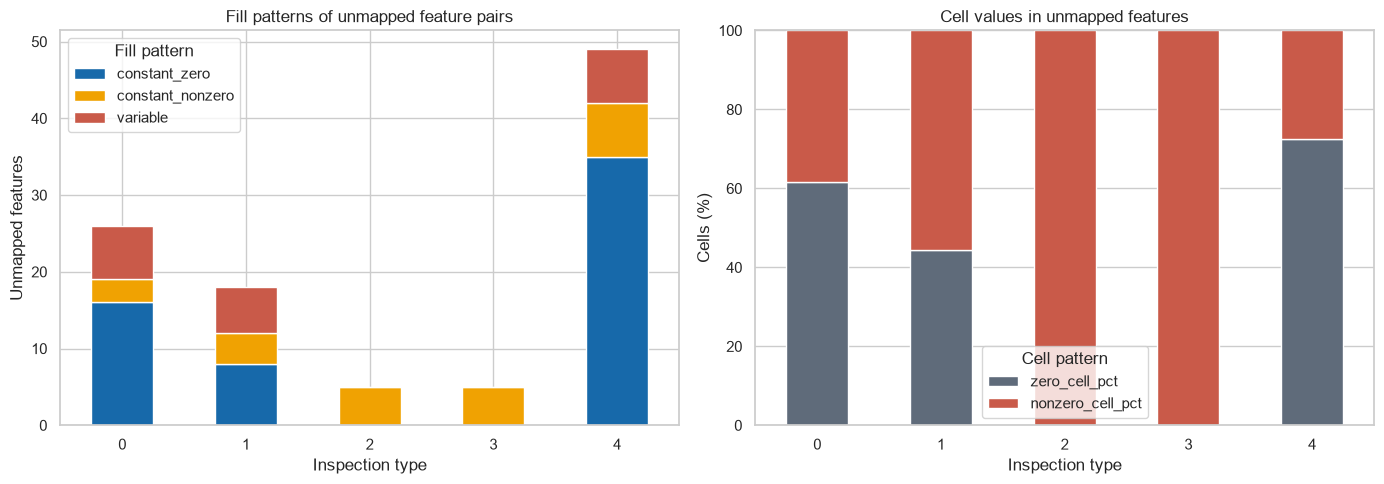

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
invalid_pattern_counts[fill_pattern_order].plot(
    kind="bar", stacked=True, color=["#1769aa", "#f0a202", "#c95a49"], ax=axes[0]
)
axes[0].set_title("Fill patterns of unmapped feature pairs")
axes[0].set_xlabel("Inspection type")
axes[0].set_ylabel("Unmapped features")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Fill pattern")

invalid_summary[["zero_cell_pct", "nonzero_cell_pct"]].plot(
    kind="bar", stacked=True, color=["#5f6b7a", "#c95a49"], ax=axes[1]
)
axes[1].set_title("Cell values in unmapped features")
axes[1].set_xlabel("Inspection type")
axes[1].set_ylabel("Cells (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Cell pattern")
plt.tight_layout()
plt.show()

## 5. 유효값과 무효 채움값의 정확 일치 위험

각 검사 피처에 대해 그 피처가 매핑된 모든 유형의 관측값 집합을 구성합니다. 이후 매핑 제외 셀의 값이 이 유효값 집합에 정확히 존재하는지 비교합니다.

이 지표는 값 기반 마스킹이 가능한지를 확인하는 진단이며, 유형이 다른 피처끼리 물리적 의미가 같다는 뜻이 아닙니다. 특히 논문이 명시하듯 같은 컬럼도 유형별 물리적 의미가 다를 수 있습니다.

In [8]:
valid_value_support = {}
for column in INSPECTION_COLUMNS:
    valid_mask = np.zeros(len(df), dtype=bool)
    for inspection_type in inspection_types:
        if column in mapping[str(inspection_type)]:
            valid_mask |= df[TYPE_COLUMN].eq(inspection_type).to_numpy()
    valid_value_support[column] = np.unique(df.loc[valid_mask, column].to_numpy())

overlap_rows = []
for row in invalid_detail.itertuples(index=False):
    values = df.loc[df[TYPE_COLUMN] == row.inspection_type, row.feature].to_numpy()
    matches = np.isin(values, valid_value_support[row.feature])
    nonzero_mask = values != 0
    overlap_rows.append(
        {
            "inspection_type": row.inspection_type,
            "feature": row.feature,
            "cells": len(values),
            "any_exact_overlap": bool(matches.any()),
            "overlap_cells": int(matches.sum()),
            "nonzero_cells": int(nonzero_mask.sum()),
            "nonzero_overlap_cells": int(matches[nonzero_mask].sum()),
        }
    )
overlap_detail = pd.DataFrame(overlap_rows)

overlap_summary_rows = []
for inspection_type in inspection_types:
    part = overlap_detail.loc[overlap_detail["inspection_type"] == inspection_type]
    total_cells = int(part["cells"].sum())
    nonzero_cells = int(part["nonzero_cells"].sum())
    overlap_summary_rows.append(
        {
            "inspection_type": inspection_type,
            "unmapped_feature_pairs": len(part),
            "pairs_with_any_exact_overlap": int(part["any_exact_overlap"].sum()),
            "pair_overlap_pct": float(part["any_exact_overlap"].mean() * 100),
            "invalid_cell_exact_overlap_pct": float(part["overlap_cells"].sum() / total_cells * 100),
            "nonzero_invalid_cell_exact_overlap_pct": (
                float(part["nonzero_overlap_cells"].sum() / nonzero_cells * 100)
                if nonzero_cells
                else np.nan
            ),
        }
    )
overlap_summary = pd.DataFrame(overlap_summary_rows).set_index("inspection_type")
display(overlap_summary)

,unmapped_feature_pairs,pairs_with_any_exact_overlap,pair_overlap_pct,invalid_cell_exact_overlap_pct,nonzero_invalid_cell_exact_overlap_pct
inspection_type,,,,,
0,26,21,80.7692,80.5611,49.4589
1,18,13,72.2222,72.0315,49.6574
2,5,0,0.0000,0.0000,0.0000
3,5,0,0.0000,0.0000,0.0000
4,49,44,89.7959,89.7959,62.9384


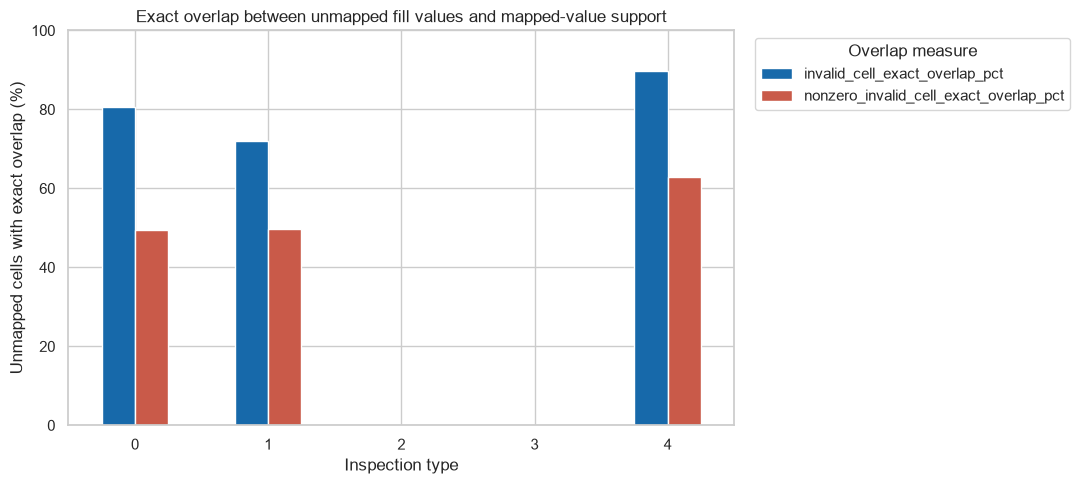

In [9]:
ax = overlap_summary[["invalid_cell_exact_overlap_pct", "nonzero_invalid_cell_exact_overlap_pct"]].plot(
    kind="bar", figsize=(11, 5), color=["#1769aa", "#c95a49"]
)
ax.set_title("Exact overlap between unmapped fill values and mapped-value support")
ax.set_xlabel("Inspection type")
ax.set_ylabel("Unmapped cells with exact overlap (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Overlap measure", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6. 안전한 전처리 규칙

1. 데이터 로딩 직후 CSV의 검사유형과 `mapping.json`의 키·피처 참조가 유효한지 검증하고, 실패하면 학습·추론을 중단합니다. 어떤 유형에도 매핑되지 않은 검사 피처는 전역 제외 대상으로 관리합니다.
2. 우선 권장안은 `inspection_type`별로 데이터를 분기하고 해당 유형에 매핑된 검사 피처만 선택하는 것입니다. 매핑 제외 셀은 값과 관계없이 모델 입력에서 제거합니다.
3. 하나의 통합 모델을 사용해야 한다면 매핑 제외 셀을 구조적 결측으로 마스킹하고 `inspection_type`을 명시적으로 포함합니다. 다만 같은 컬럼의 물리적 의미가 유형별로 다를 수 있으므로 유형별 모델 또는 유형별 상호작용을 우선 검토합니다.
4. 상수·준상수·저분산 판정은 시간 및 timestamp 그룹을 보존해 분할한 뒤 학습 데이터에만 적합합니다. 검증·테스트에는 학습 시 확정한 선택 목록을 그대로 적용합니다.
5. 메타 피처는 이 검사 피처 필터와 별도로 범주형 처리하며, 전처리 통계와 인코더도 학습 데이터에만 적합합니다.
6. 운영 시 검사유형별 매핑 피처 수, 선택된 후보 수, 매핑 제외 셀의 비0 비율을 스키마·데이터 드리프트 지표로 모니터링합니다.

## 7. 결론 및 다음 단계

아래 결론은 위 집계 결과에서 자동 생성합니다.

In [10]:
candidate_counts = valid_summary["candidate"].astype(int).to_dict()
nonzero_invalid_types = invalid_summary.index[invalid_summary["nonzero_cell_pct"] > 0].tolist()
any_overlap_types = overlap_summary.index[overlap_summary["pairs_with_any_exact_overlap"] > 0].tolist()

conclusion = f"""
### 핵심 결과

- `mapping.json`의 검사유형은 데이터의 **{len(inspection_types)}개 유형**과 일치하고 중복 참조나 CSV에 없는 참조가 없습니다. 70개 검사 피처 중 **{len(mapped_union)}개**가 적어도 한 유형에 매핑되고 **{len(never_mapped_features)}개**는 어떤 유형에도 매핑되지 않으며, 모든 유형에 공통인 피처는 **{len(mapped_intersection)}개**입니다.
- 매핑된 유효 피처 수는 type 0~4에서 각각 **{', '.join(str(int(valid_summary.loc[t, 'mapped_features'])) for t in inspection_types)}개**입니다.
- 상수·준상수·저분산을 제외한 잠정 실사용 검사 피처 후보는 type 0~4에서 각각 **{', '.join(str(candidate_counts[t]) for t in inspection_types)}개**입니다. 이는 전체 기간 EDA 결과이며 실제 제거 목록은 학습 구간에서 다시 계산해야 합니다.
- 매핑 제외 피처의 0 비율은 type별로 **{', '.join(f'{invalid_summary.loc[t, 'zero_cell_pct']:.2f}%' for t in inspection_types)}**입니다. 비0 채움이 나타난 유형은 **{', '.join(map(str, nonzero_invalid_types))}**로, 0 여부만으로 유효성을 판단할 수 없습니다.
- 매핑 제외 피처 조합 중 유효값 집합과 정확히 겹치는 조합이 존재한 유형은 **{', '.join(map(str, any_overlap_types))}**입니다. type 0·1·4에서는 비0 무효 셀도 유효값 집합과 겹치므로 단순 센티널 값이나 범위 규칙도 안전하지 않습니다.

### 해석

- 논문의 '미사용 피처는 0' 설명은 공개 CSV 전체에 일관되게 적용되지 않습니다. `mapping.json`이 유일하게 재현 가능한 유효성 기준입니다.
- type 1~3은 매핑된 피처의 상당수가 전체 기간에 걸쳐 상수이며, 유형별 피처 선택 없이는 불필요한 차원이 크게 남습니다.
- 전체 유형을 그대로 합친 단일 피처 공간은 구조적 채움값과 유형별로 다른 물리적 의미를 혼합하므로 해석과 일반화 모두에 위험합니다.

### 다음 단계

1. 시간순·timestamp 그룹 보존 분할을 먼저 확정합니다.
2. 각 학습 구간에서 유형별 상수·준상수·저분산 필터를 적합하고 검증 구간의 선택 안정성을 확인합니다.
3. 유형별 모델과 `inspection_type`을 포함한 통합 모델을 동일 분할·운영 지표로 비교합니다.
4. 선택 피처 수와 무효 채움 패턴의 시간 변화는 temporal drift 실험과 연결해 모니터링 기준을 정합니다.
"""
display(Markdown(conclusion))


### 핵심 결과

- `mapping.json`의 검사유형은 데이터의 **5개 유형**과 일치하고 중복 참조나 CSV에 없는 참조가 없습니다. 70개 검사 피처 중 **65개**가 적어도 한 유형에 매핑되고 **5개**는 어떤 유형에도 매핑되지 않으며, 모든 유형에 공통인 피처는 **17개**입니다.
- 매핑된 유효 피처 수는 type 0~4에서 각각 **44, 52, 65, 65, 21개**입니다.
- 상수·준상수·저분산을 제외한 잠정 실사용 검사 피처 후보는 type 0~4에서 각각 **27, 12, 18, 17, 10개**입니다. 이는 전체 기간 EDA 결과이며 실제 제거 목록은 학습 구간에서 다시 계산해야 합니다.
- 매핑 제외 피처의 0 비율은 type별로 **61.54%, 44.45%, 0.00%, 0.00%, 72.47%**입니다. 비0 채움이 나타난 유형은 **0, 1, 2, 3, 4**로, 0 여부만으로 유효성을 판단할 수 없습니다.
- 매핑 제외 피처 조합 중 유효값 집합과 정확히 겹치는 조합이 존재한 유형은 **0, 1, 4**입니다. type 0·1·4에서는 비0 무효 셀도 유효값 집합과 겹치므로 단순 센티널 값이나 범위 규칙도 안전하지 않습니다.

### 해석

- 논문의 '미사용 피처는 0' 설명은 공개 CSV 전체에 일관되게 적용되지 않습니다. `mapping.json`이 유일하게 재현 가능한 유효성 기준입니다.
- type 1~3은 매핑된 피처의 상당수가 전체 기간에 걸쳐 상수이며, 유형별 피처 선택 없이는 불필요한 차원이 크게 남습니다.
- 전체 유형을 그대로 합친 단일 피처 공간은 구조적 채움값과 유형별로 다른 물리적 의미를 혼합하므로 해석과 일반화 모두에 위험합니다.

### 다음 단계

1. 시간순·timestamp 그룹 보존 분할을 먼저 확정합니다.
2. 각 학습 구간에서 유형별 상수·준상수·저분산 필터를 적합하고 검증 구간의 선택 안정성을 확인합니다.
3. 유형별 모델과 `inspection_type`을 포함한 통합 모델을 동일 분할·운영 지표로 비교합니다.
4. 선택 피처 수와 무효 채움 패턴의 시간 변화는 temporal drift 실험과 연결해 모니터링 기준을 정합니다.
